# 4. Tune SA and GA with Optuna

Run two compact, validation-driven studies with native Optuna `Study` and `Trial`
objects. The SA study retains the richer repeated objective; the GA study adds a
small search over population and mutation behavior. After both selections finish,
refit each chosen configuration and evaluate the untouched test split once.

These small studies demonstrate a sound workflow. They do not establish global
optimality or compare SA and GA under equivalent compute budgets.

In [1]:
import importlib.metadata
import platform
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn

torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
started = perf_counter()
print("Python", platform.python_version(), "|", platform.system(), platform.machine())
print(
    "Versions:",
    {
        package: importlib.metadata.version(package)
        for package in [
            "pyperch",
            "torch",
            "numpy",
            "matplotlib",
            "scikit-learn",
            "optuna",
        ]
    },
)

Python 3.12.13 | Darwin arm64
Versions: {'pyperch': '0.3.2', 'torch': '2.12.0', 'numpy': '2.2.6', 'matplotlib': '3.10.9', 'scikit-learn': '1.7.2', 'optuna': '4.8.0'}


## Shared data and model

Generate 400 binary classification observations and make a stratified 60/20/20
train/validation/test split. Scale from training data only. Every fit uses a fresh
6 to 8 to 2 tanh model, float32 CPU tensors, one Torch thread, and full-batch
cross-entropy. Test observations remain untransformed until both studies have
selected configurations.

In [2]:
import optuna
from IPython.display import Markdown, display
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from pyperch.optim import GA, SA
from pyperch.plotting import plot_training_curve, prepare_training_curve
from pyperch.search import OptunaSearch

optuna.logging.set_verbosity(optuna.logging.WARNING)
X, y = make_classification(
    n_samples=400,
    n_features=6,
    n_informative=4,
    n_redundant=0,
    class_sep=1.2,
    random_state=42,
)
Xt, Xreserved, yt, yreserved = train_test_split(
    X,
    y,
    test_size=0.4,
    stratify=y,
    random_state=42,
)
Xv, Xtest_raw, yv, ytest_raw = train_test_split(
    Xreserved,
    yreserved,
    test_size=0.5,
    stratify=yreserved,
    random_state=42,
)
scaler = StandardScaler().fit(Xt)
Xt, Xv = [
    torch.tensor(scaler.transform(values), dtype=torch.float32) for values in (Xt, Xv)
]
yt, yv = [torch.tensor(values, dtype=torch.long) for values in (yt, yv)]
loss_fn = nn.CrossEntropyLoss()


def make_model(seed):
    torch.manual_seed(seed)
    return nn.Sequential(nn.Linear(6, 8), nn.Tanh(), nn.Linear(8, 2))


def validation_loss(model):
    with torch.no_grad():
        return loss_fn(model(Xv), yv).item()

## SA study

Search step size and temperature on logarithmic scales and cooling on a linear
scale. Eight serial trials each average seeds 11, 22, and 33 with 160 SA calls per
fit, including initialization. Every fit restores its lowest training-loss
checkpoint before one validation evaluation. The seeded TPE sampler uses random
startup sampling at this small trial count.

In [3]:
SA_SEEDS = [11, 22, 33]
SA_CALLS = 160


def train_sa(params, seed, record=False):
    model = make_model(seed)
    optimizer = SA(
        model.parameters(),
        **params,
        min_temperature=0.001,
        random_state=seed,
    )
    history = {"Train": [], "Validation": []}

    @torch.no_grad()
    def closure():
        return loss_fn(model(Xt), yt)

    for _ in range(SA_CALLS):
        optimizer.step(closure)
        if record:
            with torch.no_grad():
                history["Train"].append(loss_fn(model(Xt), yt).item())
                history["Validation"].append(loss_fn(model(Xv), yv).item())
    optimizer.restore_best()
    return model, validation_loss(model), optimizer.function_evals, history


sa_search = OptunaSearch(
    param_space={
        "step_size": ("float", 0.01, 0.2, True),
        "temperature": ("float", 0.005, 0.1, True),
        "cooling": ("float", 0.95, 0.995),
    },
    direction="minimize",
    study_kwargs={
        "sampler": optuna.samplers.TPESampler(seed=42),
        "study_name": "sa_teaching",
    },
)


def sa_objective(params, trial):
    losses, counts = [], []
    for seed in SA_SEEDS:
        _, valid_loss, count, _ = train_sa(params, seed)
        losses.append(valid_loss)
        counts.append(count)
    trial.set_user_attr("seeds", SA_SEEDS)
    trial.set_user_attr("validation_losses", losses)
    trial.set_user_attr("objective_evaluations", counts)
    return float(np.mean(losses))


sa_study = sa_search.search(sa_objective, n_trials=8, n_jobs=1)
rows = [
    "| Trial | State | Mean validation loss | Seed losses (11, 22, 33) |",
    "| ---: | --- | ---: | --- |",
]
for trial in sa_study.trials:
    losses = ", ".join(
        f"{value:.4f}" for value in trial.user_attrs.get("validation_losses", [])
    )
    value = "n/a" if trial.value is None else f"{trial.value:.4f}"
    rows.append(f"| {trial.number} | {trial.state.name} | {value} | {losses} |")
display(Markdown("\n".join(rows)))
print("Selected SA trial:", sa_study.best_trial.number)
print("Selected SA parameters:", sa_study.best_params)
print("Measured objective evaluations per trial seed: 160")

| Trial | State | Mean validation loss | Seed losses (11, 22, 33) |
| ---: | --- | ---: | --- |
| 0 | COMPLETE | 0.6858 | 0.6460, 0.7520, 0.6595 |
| 1 | COMPLETE | 0.6102 | 0.5994, 0.6285, 0.6027 |
| 2 | COMPLETE | 0.6984 | 0.6758, 0.7564, 0.6628 |
| 3 | COMPLETE | 0.5825 | 0.5258, 0.6038, 0.6178 |
| 4 | COMPLETE | 0.5549 | 0.5233, 0.5762, 0.5652 |
| 5 | COMPLETE | 0.6797 | 0.6478, 0.7408, 0.6504 |
| 6 | COMPLETE | 0.6441 | 0.6074, 0.6965, 0.6284 |
| 7 | COMPLETE | 0.6819 | 0.6518, 0.7423, 0.6516 |

Selected SA trial: 4
Selected SA parameters: {'step_size': 0.12106896936002161, 'temperature': 0.009445600138094694, 'cooling': 0.9581821235243195}
Measured objective evaluations per trial seed: 160


Each dot is a trial's mean validation loss; the best-value trace records
cumulative selection progress. Trial number is a search index, not a training
iteration. The individual losses show why a three-seed mean is more informative than
a single fit for this stochastic optimizer. Trial 4 has the lowest saved mean,
0.5549, without implying optimality beyond this study.

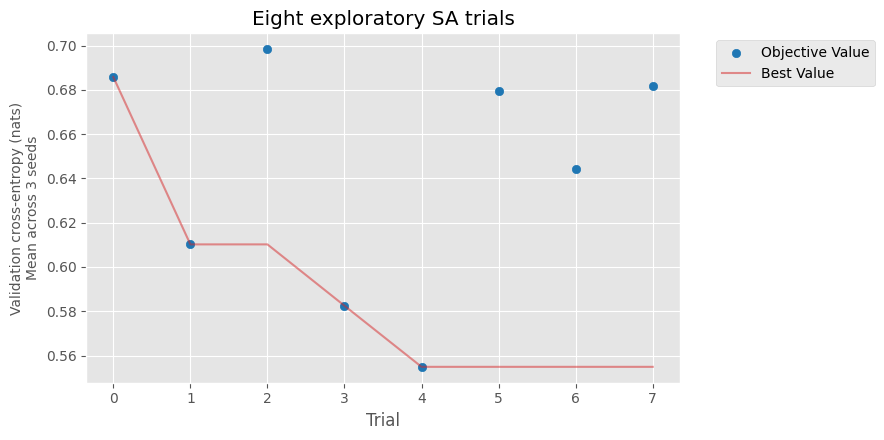

In [4]:
import warnings

from optuna.visualization.matplotlib import plot_optimization_history

with plt.rc_context():
    with warnings.catch_warnings(record=True) as plot_warnings:
        warnings.simplefilter("always", optuna.exceptions.ExperimentalWarning)
        ax = plot_optimization_history(sa_study)
    ax.set_ylabel("Validation cross-entropy (nats)\nMean across 3 seeds", fontsize=10)
    ax.set_title("Eight exploratory SA trials")
    ax.figure.set_size_inches(9, 4.5)
    ax.figure.tight_layout()
    plt.show()
for warning in plot_warnings:
    print(f"{warning.category.__name__}: {warning.message}")

## GA study

Six serial trials average seeds 11 and 22 over 90 GA calls. Search population size,
mutation rate, initialization scale, and mutation scale. Population choices are even
so the measured cost is exact: initialization evaluates `P` individuals, then each
of 89 generations evaluates `P / 2` new children while retaining elite fitness.
Validation selects configurations only after `restore_best()`.

In [5]:
GA_SEEDS = [11, 22]
GA_CALLS = 90


def train_ga(params, seed, record=False):
    model = make_model(seed)
    optimizer = GA(model.parameters(), **params, random_state=seed)
    history = {"Train": [], "Validation": []}
    evaluations = []

    @torch.no_grad()
    def closure():
        return loss_fn(model(Xt), yt)

    for _ in range(GA_CALLS):
        optimizer.step(closure)
        if record:
            with torch.no_grad():
                history["Train"].append(loss_fn(model(Xt), yt).item())
                history["Validation"].append(loss_fn(model(Xv), yv).item())
            evaluations.append(optimizer.function_evals)
    population_size = params["population_size"]
    expected_evaluations = population_size + (GA_CALLS - 1) * (population_size // 2)
    assert optimizer.function_evals == expected_evaluations
    assert optimizer.proposed_steps == GA_CALLS - 1
    assert (
        optimizer.accepted_steps + optimizer.rejected_steps == optimizer.proposed_steps
    )
    if record:
        assert np.all(np.diff(history["Train"]) <= 1e-7)
        expected_increments = [population_size] + [population_size // 2] * (
            GA_CALLS - 1
        )
        assert np.array_equal(np.diff([0] + evaluations).tolist(), expected_increments)
    optimizer.restore_best()
    with torch.no_grad():
        restored_train = loss_fn(model(Xt), yt).item()
    assert np.isclose(restored_train, optimizer.best_loss)
    return {
        "model": model,
        "valid_loss": validation_loss(model),
        "objective_evaluations": optimizer.function_evals,
        "generations": optimizer.proposed_steps,
        "improving_generations": optimizer.accepted_steps,
        "history": history,
        "evaluation_grid": evaluations,
    }


ga_search = OptunaSearch(
    param_space={
        "population_size": ("categorical", [8, 12, 16]),
        "mutation_rate": ("float", 0.05, 0.35),
        "initialization_step_size": ("float", 0.04, 0.2, True),
        "mutation_step_size": ("float", 0.01, 0.1, True),
    },
    direction="minimize",
    study_kwargs={
        "sampler": optuna.samplers.RandomSampler(seed=314),
        "study_name": "ga_teaching",
    },
)


def ga_objective(params, trial):
    runs = [train_ga(params, seed) for seed in GA_SEEDS]
    trial.set_user_attr("seeds", GA_SEEDS)
    trial.set_user_attr("validation_losses", [run["valid_loss"] for run in runs])
    trial.set_user_attr(
        "objective_evaluations",
        [run["objective_evaluations"] for run in runs],
    )
    return float(np.mean([run["valid_loss"] for run in runs]))


ga_study = ga_search.search(ga_objective, n_trials=6, n_jobs=1)
rows = [
    "| Trial | Population | Mutation rate | Initialization scale | Mutation scale | "
    "Mean validation loss | Evaluations per seed |",
    "| ---: | ---: | ---: | ---: | ---: | ---: | ---: |",
]
for trial in ga_study.trials:
    evaluations = trial.user_attrs["objective_evaluations"]
    rows.append(
        f"| {trial.number} | {trial.params['population_size']} | "
        f"{trial.params['mutation_rate']:.3f} | "
        f"{trial.params['initialization_step_size']:.3f} | "
        f"{trial.params['mutation_step_size']:.3f} | {trial.value:.4f} | "
        f"{evaluations[0]} |"
    )
display(Markdown("\n".join(rows)))
print("Selected GA trial:", ga_study.best_trial.number)
print("Selected GA parameters:", ga_study.best_params)

| Trial | Population | Mutation rate | Initialization scale | Mutation scale | Mean validation loss | Evaluations per seed |
| ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| 0 | 8 | 0.285 | 0.175 | 0.067 | 0.3580 | 364 |
| 1 | 16 | 0.128 | 0.137 | 0.018 | 0.5170 | 728 |
| 2 | 16 | 0.133 | 0.045 | 0.043 | 0.4499 | 728 |
| 3 | 16 | 0.256 | 0.081 | 0.021 | 0.4740 | 728 |
| 4 | 16 | 0.300 | 0.047 | 0.011 | 0.5603 | 728 |
| 5 | 12 | 0.211 | 0.050 | 0.024 | 0.5084 | 546 |

Selected GA trial: 0
Selected GA parameters: {'population_size': 8, 'mutation_rate': 0.28496161386252156, 'initialization_step_size': 0.17527307176279874, 'mutation_step_size': 0.0671977933648412}


Population size changes evaluation cost as well as search behavior, so these
trials do not share an evaluation budget. The exact counts make that difference
visible. The generation and fitness-reuse assertions verify persistent-population
behavior. Trial 0 selects population size 8 and uses 364 measured fitness
evaluations per seed, the smallest budget among these sampled trials.

## Refit selected configurations, then use test data

An Optuna study stores trial parameters and values, not trained model weights.
Refit each selected configuration from independent seed 44 with its original call
budget, restore its best training checkpoint, and only now evaluate test data. These
two test results are final descriptions, not a new basis for choosing between SA
and GA.

In [6]:
sa_model, sa_valid_loss, sa_evaluations, sa_history = train_sa(
    sa_study.best_params,
    seed=44,
    record=True,
)
ga_refit = train_ga(ga_study.best_params, seed=44, record=True)
Xtest = torch.tensor(scaler.transform(Xtest_raw), dtype=torch.float32)
ytest = torch.tensor(ytest_raw, dtype=torch.long)


@torch.no_grad()
def test_metrics(model):
    logits = model(Xtest)
    return {
        "loss": loss_fn(logits, ytest).item(),
        "accuracy": (logits.argmax(1) == ytest).float().mean().item(),
    }


sa_test = test_metrics(sa_model)
ga_test = test_metrics(ga_refit["model"])
print(
    f"SA refit: {sa_evaluations} objective evaluations; "
    f"validation loss {sa_valid_loss:.4f}; test loss {sa_test['loss']:.4f}; "
    f"test accuracy {sa_test['accuracy']:.3f}"
)
print(
    f"GA refit: {ga_refit['generations']} generations; "
    f"{ga_refit['objective_evaluations']} fitness evaluations; "
    f"validation loss {ga_refit['valid_loss']:.4f}; test loss {ga_test['loss']:.4f}; "
    f"test accuracy {ga_test['accuracy']:.3f}"
)
print(
    "GA generations improving the retained population best:",
    f"{ga_refit['improving_generations']} / {ga_refit['generations']}",
)

SA refit: 160 objective evaluations; validation loss 0.5873; test loss 0.5458; test accuracy 0.738
GA refit: 89 generations; 364 fitness evaluations; validation loss 0.3401; test loss 0.3732; test accuracy 0.825
GA generations improving the retained population best: 50 / 89


The SA curve uses optimizer calls, including its initial loss evaluation. The GA
views show the same restored-refit history by evolved generations and by measured
fitness evaluations. Point 0 is the initialized population before any generation is
evolved. Neither horizontal axis is an elapsed-time comparison.

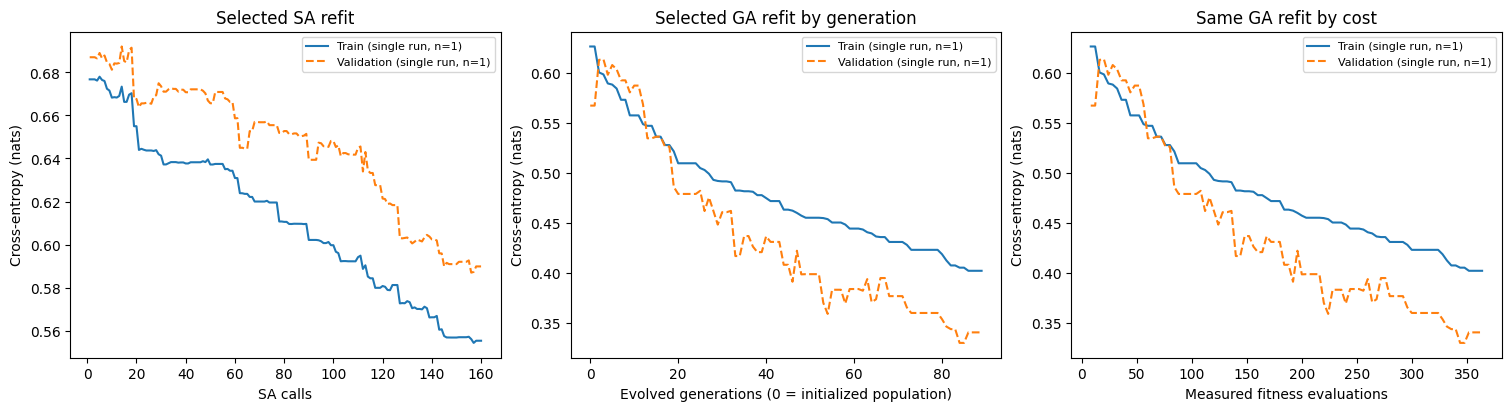

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), layout="constrained")
plot_training_curve(
    prepare_training_curve(
        np.arange(1, SA_CALLS + 1),
        sa_history,
        metric="Cross-entropy (nats)",
        x_label="SA calls",
    ),
    ax=axes[0],
)
axes[0].set_title("Selected SA refit")

ga_progress = np.arange(GA_CALLS)
plot_training_curve(
    prepare_training_curve(
        ga_progress,
        ga_refit["history"],
        metric="Cross-entropy (nats)",
        x_label="Evolved generations (0 = initialized population)",
    ),
    ax=axes[1],
)
axes[1].set_title("Selected GA refit by generation")
plot_training_curve(
    prepare_training_curve(
        ga_refit["evaluation_grid"],
        ga_refit["history"],
        metric="Cross-entropy (nats)",
        x_label="Measured fitness evaluations",
    ),
    ax=axes[2],
)
axes[2].set_title("Same GA refit by cost")
for ax in axes:
    ax.legend(fontsize=8)
plt.show()

The independent refits need not reproduce their studies' seed-averaged validation
values. In the saved run, SA uses 160 objective evaluations and reaches test
accuracy 0.738; GA uses 89 generations and 364 fitness evaluations and reaches
0.825. These single-seed results have different budgets and do not support choosing
one optimizer over the other.

See the [search guide](../../docs/search.md),
[plotting reference](../../docs/plotting.md), and
[notebook setup](../README.md).

In [8]:
print(f"Notebook computation and plotting: {perf_counter() - started:.2f} seconds")

Notebook computation and plotting: 1.49 seconds
